# Customer Churn Analysis

In this project I look at customer data from a telecom company to find out which customers leave and what they have in common. "Churn" just means a customer stops using the service. Keeping a customer is cheaper than finding a new one, so knowing who is likely to leave is useful.

The data is the Telco Customer Churn dataset: 7,043 customers and 21 columns such as contract type, tenure, monthly charges, internet service and payment method. The `Churn` column says if the customer left (Yes) or stayed (No).

In this notebook I load and clean the data, compare customers who left with customers who stayed, make some charts, and write down what I found at the end.

Tools used: Python, pandas, NumPy, Matplotlib and Seaborn.

In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the data
First I load the file and look at it: the first and last rows, the size (7,043 rows and 21 columns), the data types, basic statistics, missing values and duplicates. There are no duplicate rows.

In [287]:
cc= pd.read_csv('Telco Customer Churn.csv')

In [288]:
cc.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [289]:
cc.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [290]:
cc.shape

(7043, 21)

In [291]:
cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [292]:
cc.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [293]:
cc.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [294]:
cc.duplicated().sum()

np.int64(0)

In [295]:
cc.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## 2. Cleaning the data
`TotalCharges` was saved as text, so I changed it to a number. After that, 11 rows were empty. These are customers with 0 months of tenure, so they had not been billed yet. I removed them, which leaves 7,032 customers. I also dropped `customerID` because it is just an ID and does not help the analysis.

In [296]:
cc['TotalCharges'] = pd.to_numeric(cc['TotalCharges'],errors='coerce')
cc.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [297]:
cc = cc.dropna(subset=['TotalCharges'])
cc.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [298]:
cc.shape

(7032, 21)

In [299]:
cc=cc.drop( columns='customerID',errors='ignore')

In [300]:
cc.isnull().sum().sum()

np.int64(0)

**Target Variable**

Starting with the target column, `Churn`. Out of 7,032 customers, 1,869 left and 5,163 stayed. That is about 27%, so roughly 1 in 4 customers left.

In [301]:
cc['Churn'].value_counts()  #churn count

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [302]:
print((cc['Churn'].value_counts(normalize=True)*100).round(0))  #churn count in percentage

Churn
No     73.0
Yes    27.0
Name: proportion, dtype: float64


In [303]:
cc['Contract'].value_counts() #contract count

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

**Group by**

Next I compared customers who left with customers who stayed. The ones who left had a much shorter tenure on average (about 18 months compared to about 38) and paid more per month (about \$74 compared to about \$61).

In [304]:
cc.groupby('Churn')['tenure'].mean().round(2)

Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64

In [305]:
cc.groupby('Churn')['MonthlyCharges'].mean().round(2)

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64

Now contract type. The first table has the number of customers for each contract and churn value, and the next one turns those numbers into churn rates inside each contract type. Rates are the fair way to compare because the groups are different sizes. Month-to-month customers churn at 42.7%, one-year at 11.3% and two-year at only 2.9%.

In [306]:
Contract_churn_count = cc.groupby(['Contract','Churn']).size()
Contract_churn_count

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1306
                Yes       166
Two year        No       1637
                Yes        48
dtype: int64

In [307]:
Contract_churn_rate = pd.crosstab(cc['Contract'], cc['Churn'], normalize='index') * 100
Contract_churn_rate.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


In [308]:
sorted_contract_churn = Contract_churn_rate['Yes'].sort_values(ascending=False)
sorted_contract_churn.round(2)

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Yes, dtype: float64

In [309]:
Monthly_charge = cc.groupby('Churn')['MonthlyCharges'].agg(['mean','median','min','max']).round(2)
Monthly_charge

,mean,median,min,max
Churn,,,,
No,61.31,64.45,18.25,118.75
Yes,74.44,79.65,18.85,118.35


To see the patterns more clearly I put customers into tenure groups (0-12, 13-24, 25-36, 37-48, 49-60 and 61-72 months) and monthly charge groups (Low, Medium, High and Very High).

In [310]:
cc['TenureGroup'] = pd.cut(cc['tenure'],bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12 Months", "13-24 Months", "25-36 Months","37-48 Months", "49-60 Months", "61-72 Months"],include_lowest=True)
cc["MonthlyChargeGroup"] = pd.cut(cc["MonthlyCharges"],bins=[0, 30, 60, 90, 120],labels=["Low", "Medium", "High", "Very High"],include_lowest=True)

Churn goes down as tenure goes up: 47.7% in the first year and only 6.6% for customers with 61-72 months. For monthly charges, the Low group churns the least (9.8%) and the High (33.9%) and Very High (32.8%) groups churn the most.

In [311]:
tenure_churn = (cc.groupby("TenureGroup", observed=True)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).reset_index(name="ChurnRate"))
print("\n========== CHURN RATE BY TENURE GROUP ==========")
print(tenure_churn.round(2))
charge_churn = (cc.groupby("MonthlyChargeGroup", observed=True)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).reset_index(name="ChurnRate"))
print("\n========== CHURN RATE BY MONTHLY CHARGE GROUP ==========")
print(charge_churn.round(2))


========== CHURN RATE BY TENURE GROUP ==========
    TenureGroup  ChurnRate
0   0-12 Months      47.68
1  13-24 Months      28.71
2  25-36 Months      21.63
3  37-48 Months      19.03
4  49-60 Months      14.42
5  61-72 Months       6.61

========== CHURN RATE BY MONTHLY CHARGE GROUP ==========
  MonthlyChargeGroup  ChurnRate
0                Low       9.84
1             Medium      25.97
2               High      33.95
3          Very High      32.78


Looking at contract type and internet service together shows where the problem is. Month-to-month customers with fiber optic churn at 54.6%. Customers on a two-year contract hardly ever leave, whatever internet service they have.

In [312]:
service_churn = (cc.groupby(["Contract", "InternetService"])["Churn"].apply(lambda x: (x == "Yes").mean() * 100).reset_index(name="ChurnRate"))
print("\n========== CHURN RATE BY CONTRACT + INTERNET SERVICE ==========")
print(service_churn.round(2))


========== CHURN RATE BY CONTRACT + INTERNET SERVICE ==========
         Contract InternetService  ChurnRate
0  Month-to-month             DSL      32.22
1  Month-to-month     Fiber optic      54.61
2  Month-to-month              No      18.89
3        One year             DSL       9.30
4        One year     Fiber optic      19.29
5        One year              No       2.48
6        Two year             DSL       1.93
7        Two year     Fiber optic       7.23
8        Two year              No       0.79


**crosstab**

In [313]:
print("\n=====CONTRACT VS CHURN COUNT=====")
print(pd.crosstab(cc['Contract'],cc['Churn']))
print('\n=====CONTRACT VS CHURN RATE=====')
print((pd.crosstab(cc['Contract'],cc['Churn'],normalize='index')*100).round(2))
print('\n=====CONTRACTS SORTED BY CHURN RATE=====')
print((sorted_contract_churn.round(2)))


=====CONTRACT VS CHURN COUNT=====
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48

=====CONTRACT VS CHURN RATE=====
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85

=====CONTRACTS SORTED BY CHURN RATE=====
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Yes, dtype: float64


**Group Analysis**

A few more averages. Customers who left have lower total charges (about \$1,532 compared to \$2,555), which makes sense because they stayed for less time. Average tenure also grows with contract length: about 18 months for month-to-month, 42 for one-year and 57 for two-year.

In [314]:
print("\n=====AVERAGE TOTAL CHARGES BY CHURN=====")
print(cc.groupby("Churn")["TotalCharges"].mean().round(2))

print("\n=====AVERAGE TENURE BY CONTRACT=====")
print(cc.groupby("Contract")["tenure"].mean().round(2))

print("\n=====AVERAGE MONTHLY CHARGES BY CONTRACT=====")
print(cc.groupby("Contract")["MonthlyCharges"].mean().round(2))


=====AVERAGE TOTAL CHARGES BY CHURN=====
Churn
No     2555.34
Yes    1531.80
Name: TotalCharges, dtype: float64

=====AVERAGE TENURE BY CONTRACT=====
Contract
Month-to-month    18.04
One year          42.07
Two year          57.07
Name: tenure, dtype: float64

=====AVERAGE MONTHLY CHARGES BY CONTRACT=====
Contract
Month-to-month    66.40
One year          65.08
Two year          60.87
Name: MonthlyCharges, dtype: float64


In [315]:
cc.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,Low
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36 Months,Medium
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,Medium
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48 Months,Medium
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,High


In [316]:
cc['MonthlyChargeGroup'].isna().sum()

np.int64(0)

**Visualization**

Now the charts. This first one shows that about 1 in 4 customers left, so there are more customers who stayed than who left.

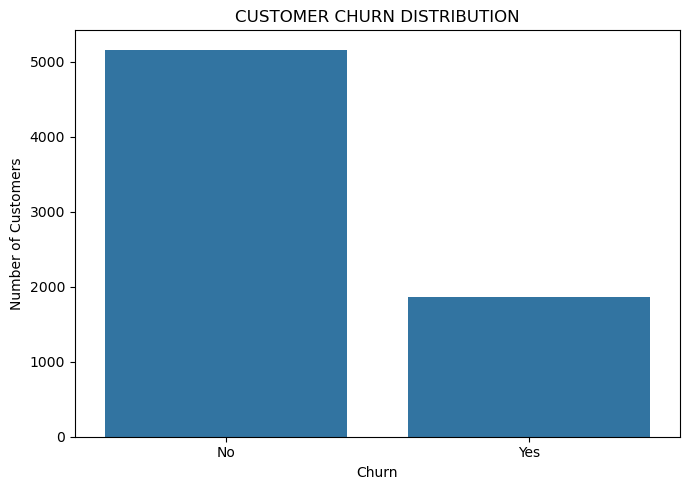

In [317]:
plt.figure(figsize=(7, 5))
sns.countplot(data=cc,x="Churn")
plt.title("CUSTOMER CHURN DISTRIBUTION")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Most customers are on a month-to-month contract, and that group also has the most customers who left.

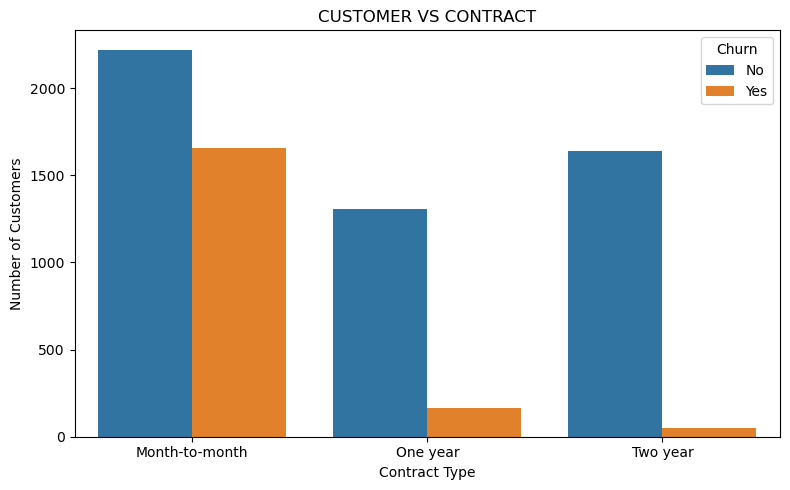

In [318]:
plt.figure(figsize=(8,5))
sns.countplot(data=cc,x='Contract',hue='Churn')
plt.title("CUSTOMER VS CONTRACT")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Churn rate by contract type. Month-to-month is much higher (42.7%) than one-year (11.3%) or two-year (2.9%).

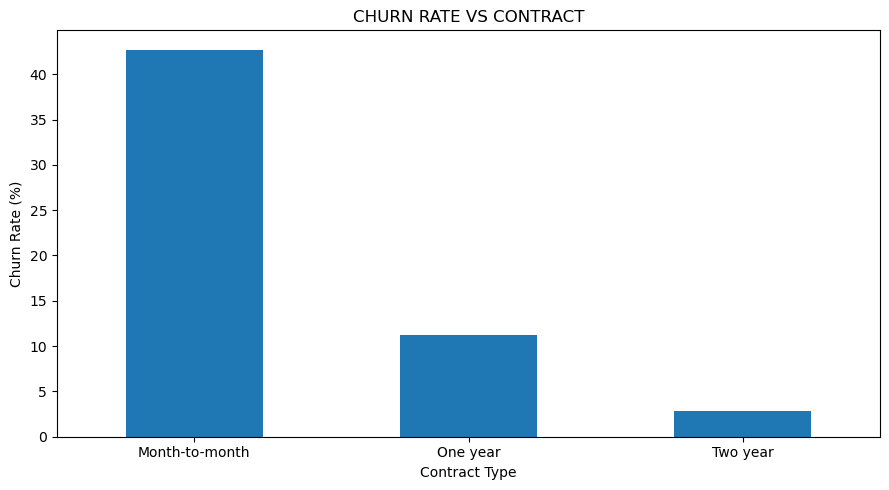

In [319]:
Contract_churn_rate['Yes'].plot(kind="bar",figsize=(9, 5))
plt.title("CHURN RATE VS CONTRACT")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Tenure distribution. Quite a lot of customers are very new, and a lot are long-term customers at around 72 months.

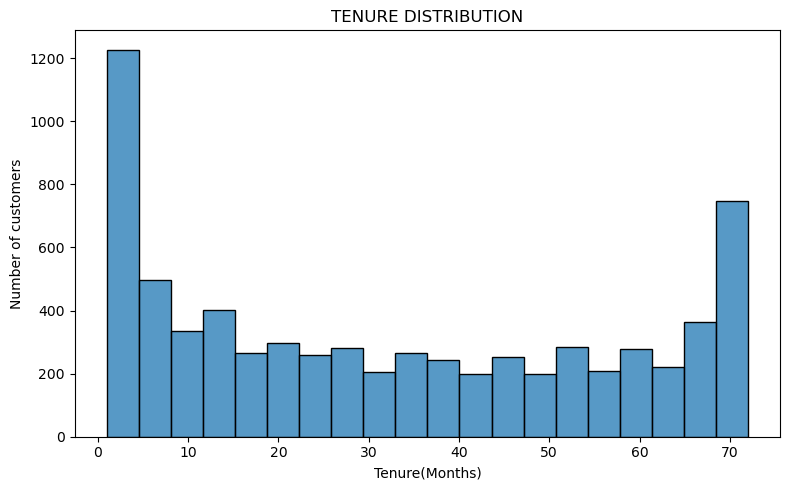

In [320]:
plt.figure(figsize=(8,5))
sns.histplot(data=cc,x='tenure',bins=20)
plt.title("TENURE DISTRIBUTION")
plt.xlabel('Tenure(Months)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

Customers who left had a much lower average tenure than customers who stayed.

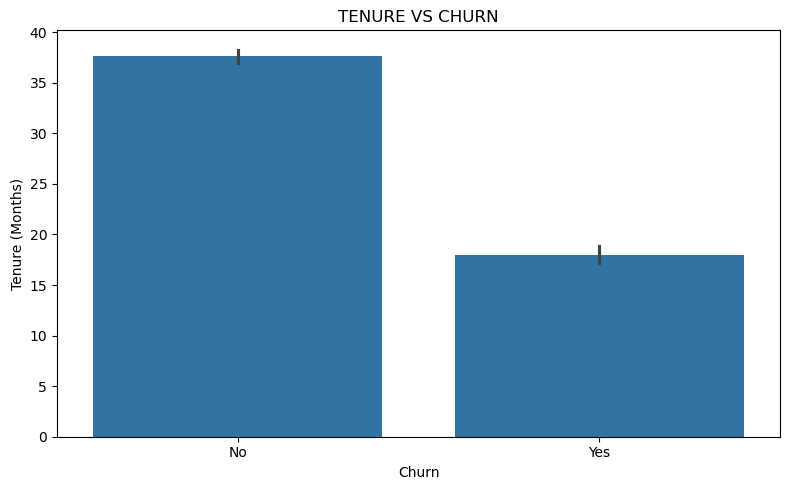

In [321]:
plt.figure(figsize=(8,5))
sns.barplot(data=cc,x='Churn',y='tenure')
plt.title("TENURE VS CHURN")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

The longer a customer stays, the less likely they are to leave. The first year is the riskiest.

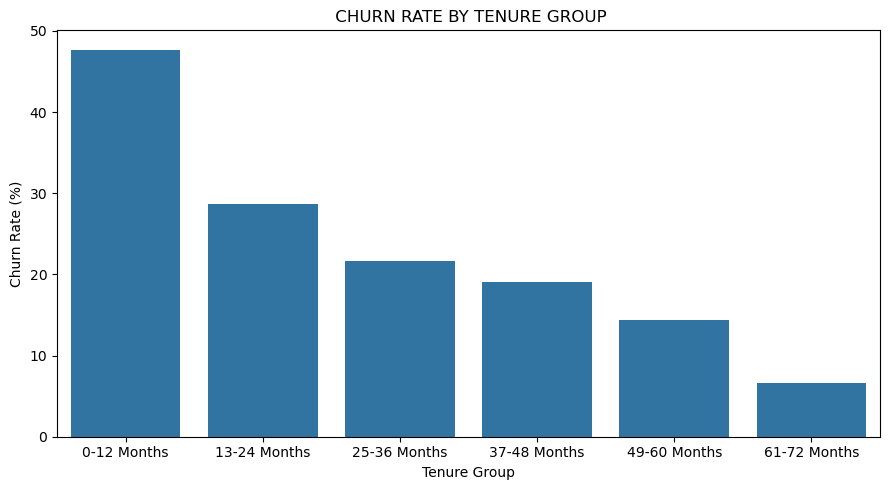

In [322]:
plt.figure(figsize=(9, 5))
sns.barplot(data=tenure_churn,x="TenureGroup",y="ChurnRate")
plt.title(" CHURN RATE BY TENURE GROUP")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

Customers who left paid more per month on average.

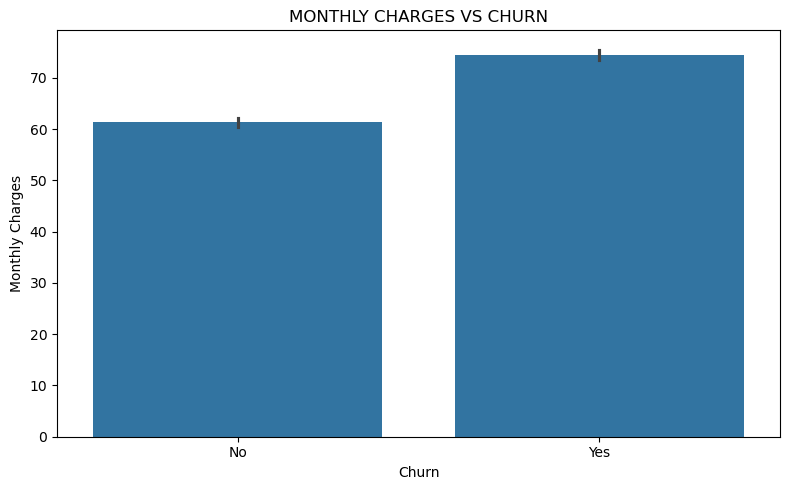

In [323]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cc,x="Churn",y="MonthlyCharges")
plt.title("MONTHLY CHARGES VS CHURN")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

Churn is lowest for low bills and highest for high and very high bills.

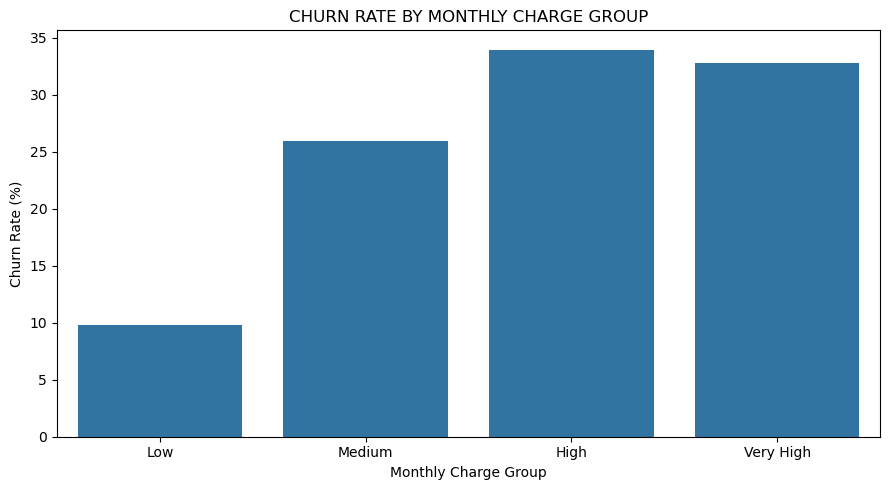

In [324]:
plt.figure(figsize=(9, 5))
sns.barplot(data=charge_churn,x="MonthlyChargeGroup",y="ChurnRate")
plt.title("CHURN RATE BY MONTHLY CHARGE GROUP")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

Fiber optic customers leave the most (roughly 4 in 10), DSL is lower (roughly 2 in 10), and customers with no internet service rarely leave.

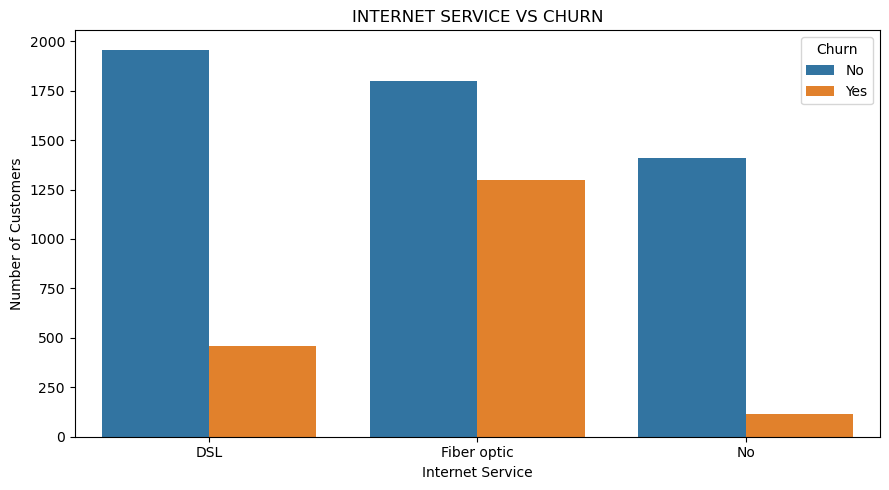

In [325]:
plt.figure(figsize=(9, 5))
sns.countplot(data=cc,x="InternetService",hue="Churn")
plt.title("INTERNET SERVICE VS CHURN")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Customers without tech support leave much more (roughly 4 in 10) than customers who have it (roughly 1.5 in 10).

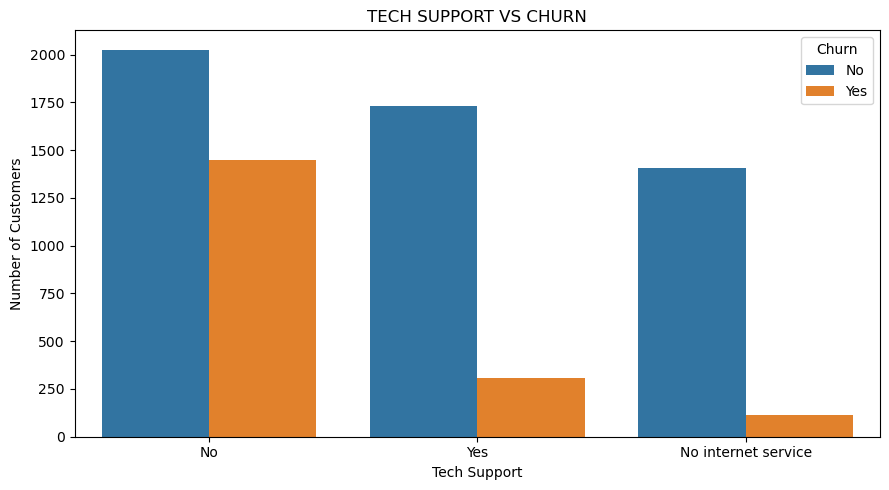

In [326]:
plt.figure(figsize=(9, 5))
sns.countplot(data=cc,x="TechSupport",hue="Churn")
plt.title("TECH SUPPORT VS CHURN")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


Customers who pay by electronic check leave the most (roughly 45%). For mailed check and automatic payments it is roughly 15-20%.

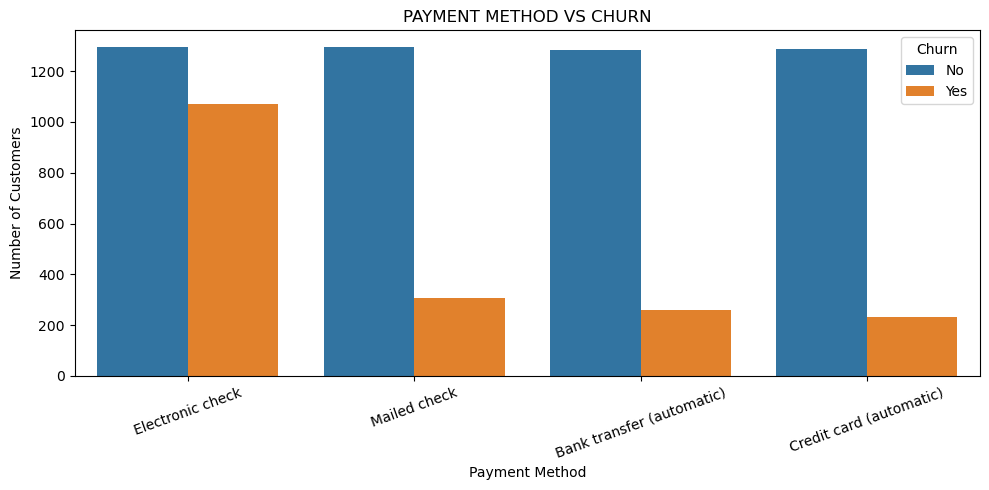

In [327]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cc,x="PaymentMethod",hue="Churn")
plt.title("PAYMENT METHOD VS CHURN")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Senior citizens are a smaller group, but a bigger share of them leave (roughly 4 in 10 compared to about 1 in 4 for non-seniors).

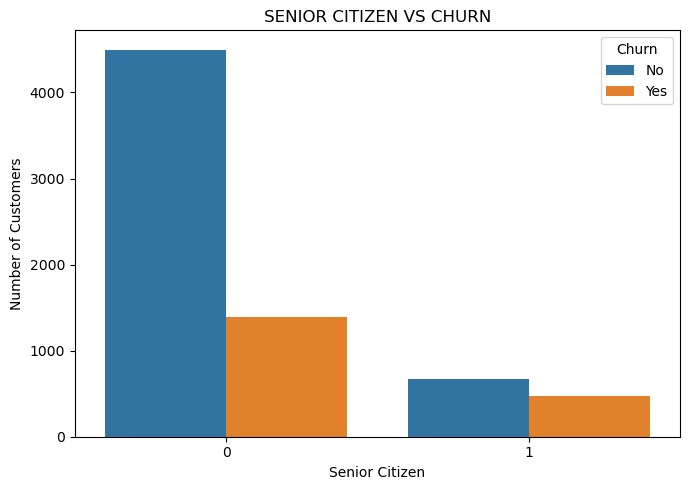

In [328]:
plt.figure(figsize=(7, 5))
sns.countplot(data=cc,x="SeniorCitizen",hue="Churn")
plt.title("SENIOR CITIZEN VS CHURN")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


Customers without a partner leave more than customers with a partner.

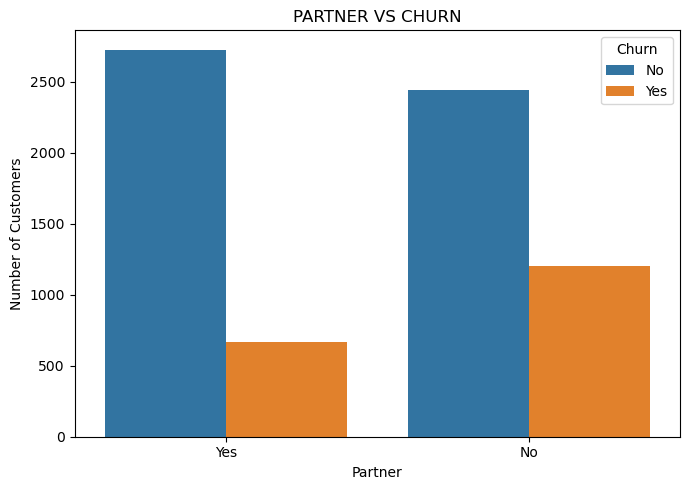

In [329]:
plt.figure(figsize=(7, 5))
sns.countplot(data=cc,x="Partner",hue="Churn")
plt.title("PARTNER VS CHURN")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Customers without dependents leave about twice as often as customers with dependents.

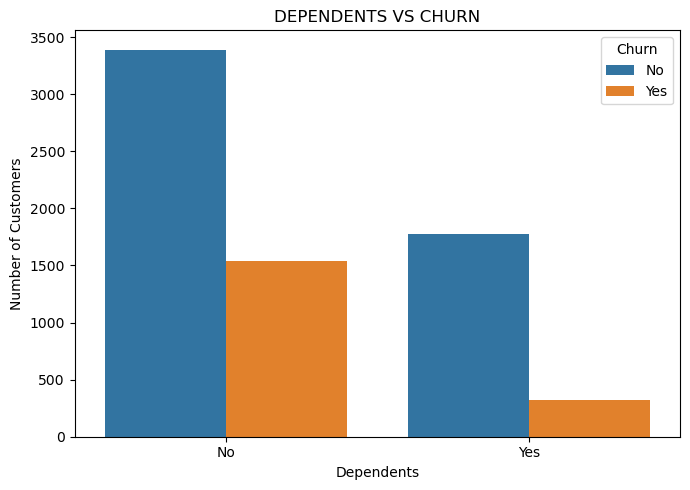

In [330]:
plt.figure(figsize=(7, 5))
sns.countplot(data=cc,x="Dependents",hue="Churn")
plt.title("DEPENDENTS VS CHURN")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Each dot is one customer. The ones who left (orange) are mostly at short tenure with higher monthly charges, and long-tenure customers mostly stayed.

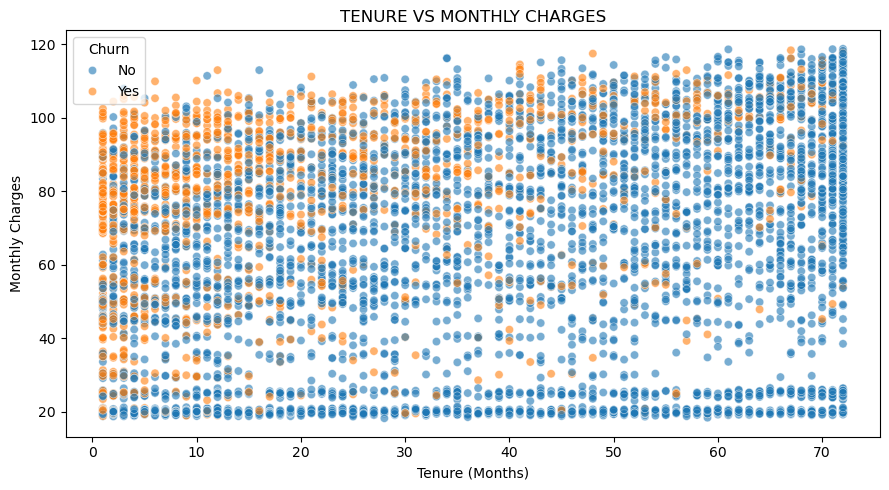

In [331]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=cc,x="tenure",y="MonthlyCharges",hue="Churn",alpha=0.6)
plt.title("TENURE VS MONTHLY CHARGES")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

This chart puts contract and internet service together. Month-to-month fiber customers have the highest churn, and two-year contracts have almost none.

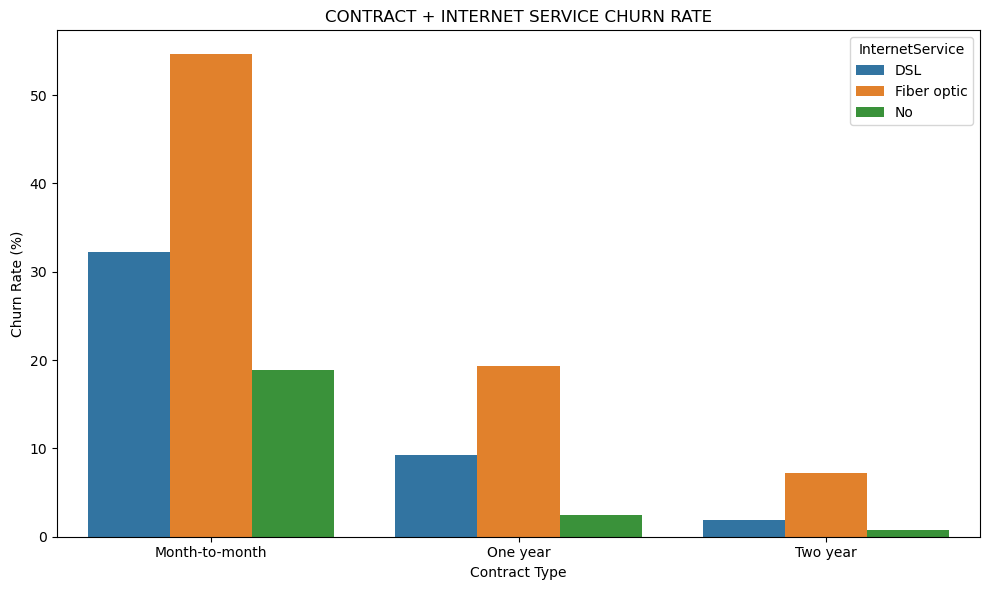

In [332]:
plt.figure(figsize=(10, 6))
sns.barplot(data=service_churn,x="Contract",y="ChurnRate",hue="InternetService")
plt.title("CONTRACT + INTERNET SERVICE CHURN RATE")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()


## 3. Summary
The last code cell collects the main numbers in one place: total customers, how many left and how many stayed, the overall churn rate, and the groups with the highest churn.

In [333]:
total_customers = len(cc)

churned_customers = (cc["Churn"] == "Yes").sum()

retained_customers = (cc["Churn"] == "No").sum()

overall_churn_rate = (churned_customers / total_customers) * 100

print("\n============================================================")
print("                    CUSTOMER SUMMARY")
print("============================================================")

print(f"Total customers: {total_customers:,}")
print(f"Churned customers: {churned_customers:,}")
print(f"Retained customers: {retained_customers:,}")
print(f"Overall churn rate: {overall_churn_rate:.2f}%")

print("\nHighest contract churn rate:")
print(sorted_contract_churn.head(1).round(2))

print("\nAverage tenure by churn:")
print(cc.groupby("Churn")["tenure"].mean().round(2))

print("\nAverage monthly charges by churn:")
print(cc.groupby("Churn")["MonthlyCharges"].mean().round(2))

print("\nHighest tenure-group churn rate:")
print(tenure_churn.sort_values("ChurnRate",ascending=False).head())

print("\nHighest monthly-charge-group churn rate:")
print(charge_churn.sort_values("ChurnRate",ascending=False).head())



                    CUSTOMER SUMMARY
Total customers: 7,032
Churned customers: 1,869
Retained customers: 5,163
Overall churn rate: 26.58%

Highest contract churn rate:
Contract
Month-to-month    42.71
Name: Yes, dtype: float64

Average tenure by churn:
Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64

Average monthly charges by churn:
Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64

Highest tenure-group churn rate:
    TenureGroup  ChurnRate
0   0-12 Months  47.678161
1  13-24 Months  28.710938
2  25-36 Months  21.634615
3  37-48 Months  19.028871
4  49-60 Months  14.423077

Highest monthly-charge-group churn rate:
  MonthlyChargeGroup  ChurnRate
2               High  33.948804
3          Very High  32.777458
1             Medium  25.969913
0                Low   9.836066


## Key findings

- About 26.6% of customers left (1,869 out of 7,032), so roughly 1 in 4.
- Contract type matters the most. Month-to-month customers churn at 42.7%, compared to 11.3% for one-year and 2.9% for two-year contracts.
- New customers are the most likely to leave. Churn is 47.7% in the first 12 months and drops to 6.6% for customers with 61-72 months.
- The highest risk group is month-to-month customers with fiber optic internet, at 54.6%.
- Customers who left paid more per month on average (about \$74 compared to about \$61). Customers with high or very high bills churn at roughly 33-34%.
- From the charts, customers without tech support, customers who pay by electronic check and senior citizens also leave more.
- Customers with a partner or dependents are more likely to stay.

## Recommendations

- Offer discounts or deals to move month-to-month customers onto a one or two year plan.
- Give extra attention to customers in their first year, for example a welcome offer or an early check-in, since that is when most of them leave.
- Find out why fiber optic customers leave so much. It could be price, service quality or competition.
- Promote tech support, since customers who have it leave much less.
- Encourage automatic payments, because customers who pay by electronic check leave far more.

## Limitations and next steps

This analysis shows relationships, not causes. For example, fiber customers leave more, but the data does not say why. Some factors also overlap (new customers are often on month-to-month contracts), so the charts alone cannot separate their effects. The next step is a prediction model, such as logistic regression or a random forest, to see which factors matter most and to find customers who are likely to leave.